# Chain-of-Prompts (CoP): Minimal Demo
### *One Click per Cell Type Suffices*: MICCAI 2026 Early Accept (Top 9%)

The simplest possible run: give **one click per cell type** and watch CoP expand each
click into every same-type cell. **Image only**, no ground truth, no metrics.

Each round adds one click; cells discovered in that round get a new color.

## 1. Setup

In [1]:
import os, math
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.sam import ImageSAM
from core.cop import ChainOfPrompts

plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold"})

# SAM3 checkpoint directory (edit to your local / Hugging Face path)
MODEL_DIR = "I:/cache/sam3" if os.name == "nt" else "/mnt/nas5/cache/sam3"

## 2. Load an image and set the clicks

Provide one `(x, y)` click per cell type. Here we reuse the same image and click order
as Figure 2, but **nothing else is needed**, just an image and the clicks.

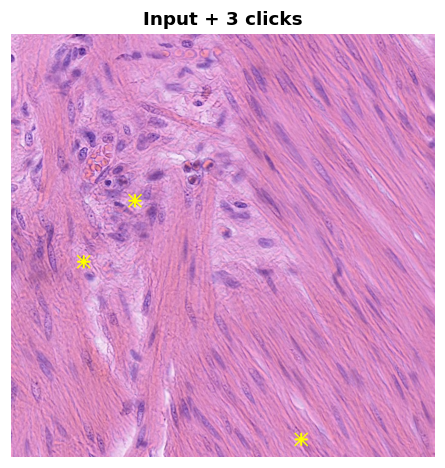

In [2]:
IMAGE_PATH = "./examples/CoNSeP_test_2.png"
CLICKS     = [(292, 395), (171, 539), (684, 958)]   # one click per cell type

cv_image = cv2.imread(IMAGE_PATH)          # BGR

vis = cv_image.copy()
for i, (x, y) in enumerate(CLICKS):
    cv2.drawMarker(vis, (x, y), (0, 255, 255), cv2.MARKER_STAR, 28, 3)
plt.figure(figsize=(5,5))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"Input + {len(CLICKS)} clicks"); plt.show()

## 3. Run Chain-of-Prompts

`segment_steps` yields the cumulative result after each click. We color cells by the
round that discovered them and show the three rounds side by side.

  round 1: +1 click  →  152 cells (+151 propagated)
  round 2: +1 click  →  167 cells (+15 propagated)
  round 3: +1 click  →  185 cells (+18 propagated)


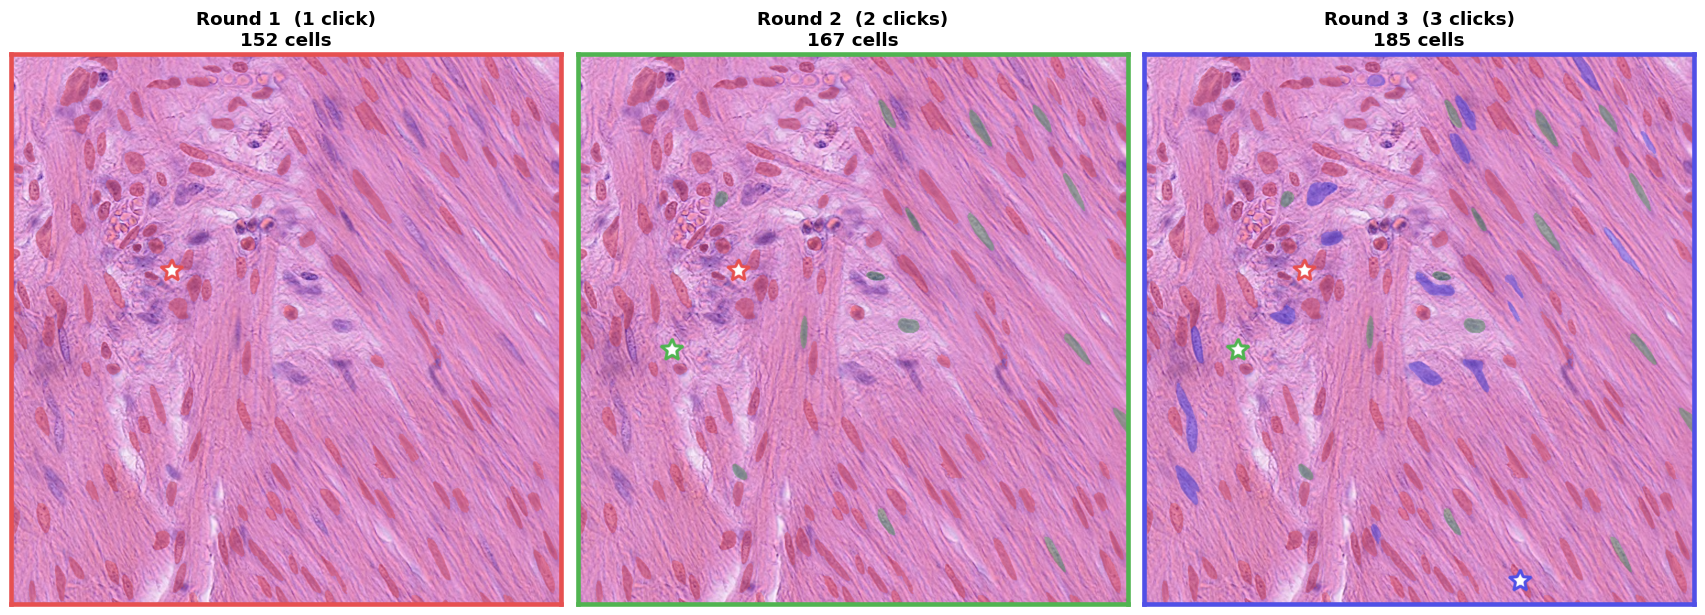

In [5]:
ROUND_RGB = [(230,80,80), (80,180,80), (80,80,230), (230,180,40), (180,80,230)]
def _bgr(c): return (int(c[2]), int(c[1]), int(c[0]))

def _star(img, cx, cy, r, t, color):
    pts = [[int(cx + (r if i%2==0 else r*0.45)*math.cos(math.pi/2 + i*math.pi/5)),
            int(cy - (r if i%2==0 else r*0.45)*math.sin(math.pi/2 + i*math.pi/5))] for i in range(10)]
    pts = np.array(pts, np.int32)
    cv2.fillPoly(img, [pts], (255,255,255)); cv2.polylines(img, [pts], True, color, t, cv2.LINE_AA)

def render(cv_bgr, label_map, inst_to_round, clicks_so_far, alpha=0.4):
    canvas = cv_bgr.copy().astype(np.float32)
    fill = np.zeros_like(canvas); m_any = np.zeros(label_map.shape, bool)
    for iid, rd in inst_to_round.items():
        m = label_map == iid
        if m.any(): fill[m] = _bgr(ROUND_RGB[rd % len(ROUND_RGB)]); m_any |= m
    canvas[m_any] = (1-alpha)*canvas[m_any] + alpha*fill[m_any]
    canvas = canvas.astype(np.uint8)
    base = max(cv_bgr.shape[:2]); sr,tk = max(int(base*0.02),7), max(int(base*0.003),1)
    for rd, (x, y) in enumerate(clicks_so_far):
        _star(canvas, int(x), int(y), sr, tk, _bgr(ROUND_RGB[rd % len(ROUND_RGB)]))
    return canvas

model = ImageSAM(MODEL_DIR, "sam3")
cop   = ChainOfPrompts(model)

panels = []
for step in cop.segment_steps(cv_image, CLICKS):
    rd = step["click_index"]
    panel = render(cv_image, step["label_map"], step["inst_to_click"], CLICKS[:rd+1])
    panels.append((rd, step["num_instances"], panel))
    print(f"  round {rd+1}: +1 click  →  {step['num_instances']} cells "
          f"(+{len(step['propagated_points'])} propagated)")

fig, axes = plt.subplots(1, len(panels), figsize=(5.2*len(panels), 5.4))
# fig.suptitle("One click per cell type → all same-type cells", fontsize=13, fontweight="bold")
for ax, (rd, n, panel) in zip(np.atleast_1d(axes), panels):
    ax.imshow(cv2.cvtColor(panel, cv2.COLOR_BGR2RGB)); ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values(): s.set_color("#%02x%02x%02x" % ROUND_RGB[rd % len(ROUND_RGB)]); s.set_linewidth(3)
    ax.set_title(f"Round {rd+1}  ({rd+1} click{'s' if rd else ''})\n{n} cells")
plt.tight_layout(); plt.show()

## 4. Final result

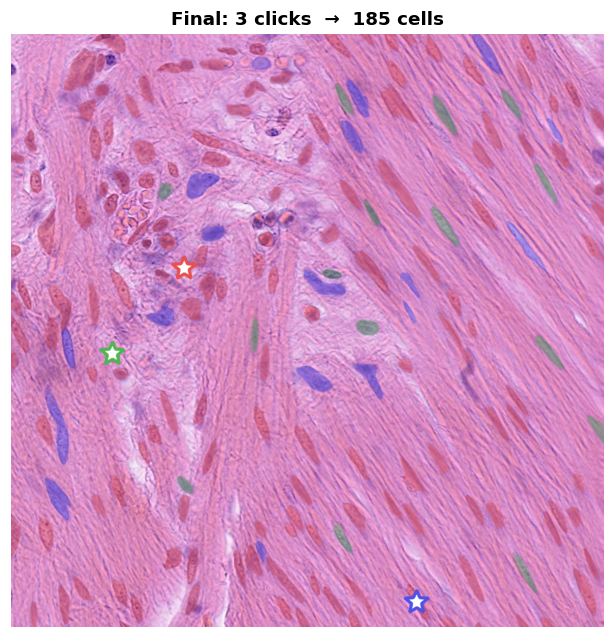

3 clicks segmented 185 cells (training-free).


In [6]:
final_rd, final_n, final_panel = panels[-1]
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(final_panel, cv2.COLOR_BGR2RGB)); plt.axis("off")
plt.title(f"Final: {len(CLICKS)} clicks  →  {final_n} cells"); plt.show()
print(f"{len(CLICKS)} clicks segmented {final_n} cells (training-free).")